Connected to reactive-agent (3.11.x) (Python 3.11.-1)

 # Agent graph

 **Where everything connects** — nodes, edges, routing logic, compiled into one object.


In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph
from app.agent.memory.short_term import init_checkpointer, get_checkpointer
from app.agent.state import AgentState
from app.agent.nodes.input_validation import input_validation_node
from app.agent.nodes.planner import planner_node
from app.agent.nodes.agent_llm import agent_llm_node
from app.agent.nodes.tools_executor import tool_executor_node
from app.agent.nodes.output_validation import output_validation_node
from app.agent.nodes.human_loop import human_loop_node
from app.core.config import get_settings

settings = get_settings()

 ## `should_continue`

 Main routing function called after every `agent` node execution.
 Checks state in priority order — order matters:

 1. `blocked` → end immediately, skip output validation
 2. `iterations >= max_iterations` → force to output validation, prevent infinite ReAct loops
 3. Tool calls + approval required → route to `human_loop`
 4. Tool calls → route to `tools`
 5. No tool calls → route to `output_validation`

 The iteration cap is what prevents the LLM from looping forever
 if it keeps calling tools without converging.

In [ ]:
def should_continue(state: AgentState) -> str:
    if state.get("blocked"):
        return "blocked"

    if state.get("iterations", 0) >= state.get("max_iterations", 10):
        return "max_reached"

    messages = state.get("messages", [])
    if not messages:
        return "end"

    last_message = messages[-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        if state.get("requires_human_approval") and not state.get("human_approved"):
            return "human_approval"
        return "tools"

    return "output_validation"

 ## `after_output_validation`

 `output_validation → agent` (via `retry`) — if output validation fails
 and iterations haven't maxed out, the agent gets another chance.
 Capped by `max_iterations` to prevent retrying forever.

In [ ]:
def after_output_validation(state: AgentState) -> str:
    if not state.get("output_validated"):
        if state.get("iterations", 0) >= state.get("max_iterations", 10):
            return "end"
        return "retry"
    return "end"

 ## `after_human_loop`

 Two outcomes after the interrupt resolves:
 - Approved → proceed to `tools`
 - Rejected → `blocked: True` was set in `human_loop_node` → END

In [ ]:
def after_human_loop(state: AgentState) -> str:
    if state.get("blocked"):
        return "blocked"
    return "tools"

 ## `build_agent_graph`

 **Fixed edges:**
 ```
 START → input_validation → planner → agent
 tools → agent   (ReAct loop)
 ```

 `tools → agent` is a fixed edge — after tool execution, always go back to the agent.
 The agent decides again: call more tools, or respond directly. That's the ReAct loop.

 **Compiled with checkpointer** — every node execution is persisted to PostgreSQL.
 This is what makes `interrupt()` in `human_loop` possible.

In [ ]:
def build_agent_graph(checkpointer) -> CompiledStateGraph:
    graph = StateGraph(AgentState)

    graph.add_node("input_validation", input_validation_node)
    graph.add_node("planner", planner_node)
    graph.add_node("agent", agent_llm_node)
    graph.add_node("tools", tool_executor_node)
    graph.add_node("output_validation", output_validation_node)
    graph.add_node("human_loop", human_loop_node)

    graph.add_edge(START, "input_validation")
    graph.add_edge("input_validation", "planner")
    graph.add_edge("planner", "agent")
    graph.add_edge("tools", "agent")

    graph.add_conditional_edges(
        "agent",
        should_continue,
        {
            "tools":             "tools",
            "output_validation": "output_validation",
            "human_approval":    "human_loop",
            "blocked":           END,
            "max_reached":       "output_validation",
            "end":               END,
        }
    )

    graph.add_conditional_edges(
        "output_validation",
        after_output_validation,
        {"retry": "agent", "end": END}
    )

    graph.add_conditional_edges(
        "human_loop",
        after_human_loop,
        {"tools": "tools", "blocked": END}
    )

    return graph.compile(checkpointer=checkpointer)

 ## Singleton — `init_agent` / `get_agent`

 The graph is compiled once at FastAPI startup — compiling is expensive,
 you don't want it happening per request.

 `get_agent()` raises immediately if called before `init_agent()` —
 same fail-fast pattern as `get_checkpointer()` in `short_term.py`.

 Startup order is required:
 1. `init_checkpointer()` — psycopg3 pool + LangGraph tables
 2. `build_agent_graph(get_checkpointer())` — graph compiled with the pool

In [ ]:
_compiled_graph: CompiledStateGraph | None = None


async def init_agent() -> None:
    global _compiled_graph
    await init_checkpointer()
    _compiled_graph = build_agent_graph(get_checkpointer())


def get_agent() -> CompiledStateGraph:
    if _compiled_graph is None:
        raise RuntimeError("Graph not initialized — call init_agent() at startup")
    return _compiled_graph

 Here is the final graph : the user input must be validate first and then send to the llm for for the next step. from the llm others process including tools calling , human approvation , output validation  or planning  wait for the llm action

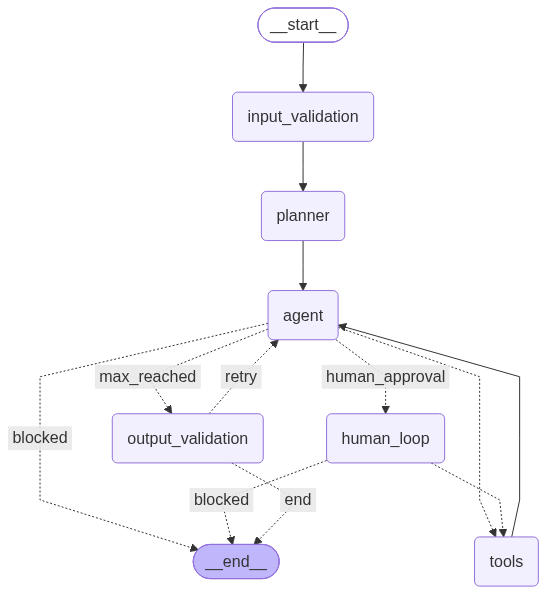

In [ ]:
from IPython.display  import  display  , Image
from langgraph.checkpoint.memory import  MemorySaver


GRAPH = build_agent_graph(MemorySaver())
display(Image(GRAPH.get_graph().draw_mermaid_png()))